In [1]:
json_train_small_path = './noisy_CWWS_train_small.json'
json_train_mono_path = './noisy_CWWS_train_mono.json'
json_train_validation_path = './noisy_CWWS_validation.json'
json_train_test_path = './noisy_CWWS_test.json'

path_tsv_files = '/home/fderrida/Desktop/mount_jz_scratch/domainbed/data/URGENT/corpus/CommonVoice/tsv_files/'

# path_tsv_files = 'path/corpus/CommonVoice/tsv_files/'

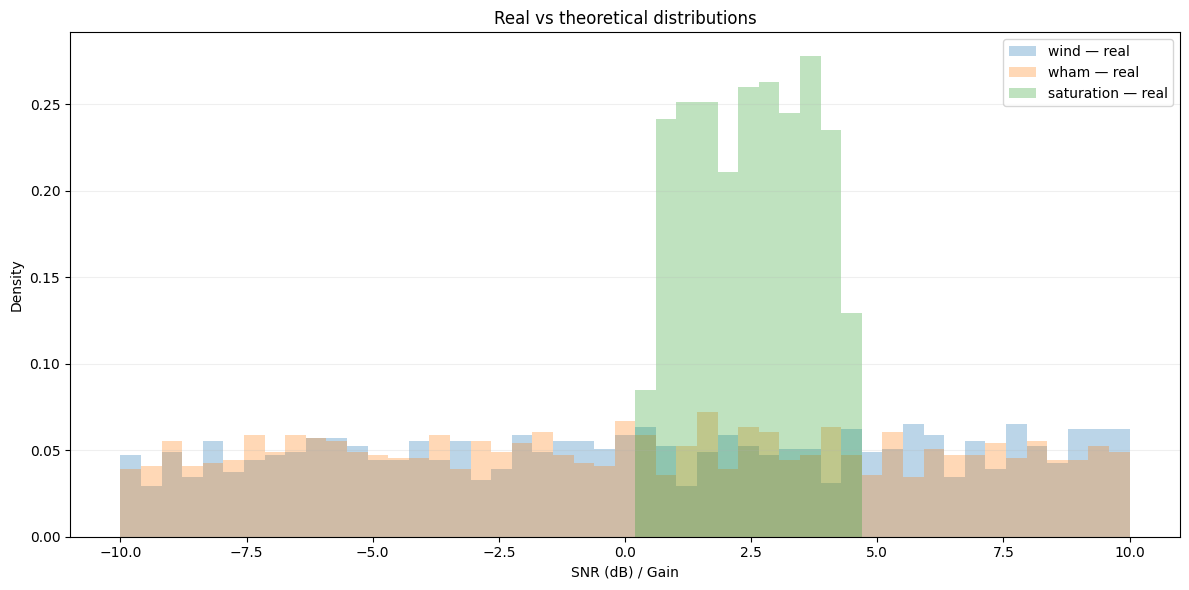

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import triang

# --------------------------------------------------
# Load JSON
# --------------------------------------------------
with open(json_train_small_path, "r") as f:
    config = json.load(f)

df = pd.DataFrame(config["data"])

# --------------------------------------------------
# Group noise types
# --------------------------------------------------
df["noise_group"] = np.select(
    [
        df["noise"].str.contains("wham", case=False, na=False),
        df["noise"].eq("wind"),
        df["noise"].eq("saturation"),
    ],
    [
        "wham",
        "wind",
        "saturation",
    ],
    default=None
)

df = df.dropna(subset=["noise_group"])


# --------------------------------------------------
# Define the value to plot
#
# wind / wham -> snr_db
# saturation  -> gain
# --------------------------------------------------
df["plot_value"] = np.where(
    df["noise_group"].eq("saturation"),
    df["gain"],
    df["snr_db"]
)

df = df.dropna(subset=["plot_value"])


# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))

colors = {
    "wind": "tab:blue",
    "wham": "tab:orange",
    "saturation": "tab:green",
}


# --------------------------------------------------
# Real distributions
# --------------------------------------------------

# Use common bins covering both SNR and gain
bins = np.linspace(
    df["plot_value"].min(),
    df["plot_value"].max(),
    50
)

for noise in ["wind", "wham", "saturation"]:

    values = df.loc[
        df["noise_group"] == noise,
        "plot_value"
    ]

    ax.hist(
        values,
        bins=bins,
        density=True,
        alpha=0.30,
        color=colors[noise],
        label=f"{noise} — real"
    )


# --------------------------------------------------
# Theoretical SNR distributions
# --------------------------------------------------
sampler_info = config["sampler_info"]

theoretical_ranges = {
    "wind": sampler_info["wind_snr_range"],
    "wham": sampler_info["wham_snr_range"],
}

# --------------------------------------------------
# Formatting
# --------------------------------------------------
ax.set_xlabel("SNR (dB) / Gain")
ax.set_ylabel("Density")
ax.set_title("Real vs theoretical distributions")

ax.grid(axis="y", alpha=0.2)
ax.legend()

plt.tight_layout()
plt.show()

In [3]:
import json
from collections import defaultdict

with open(json_train_small_path, "r") as f:
    data = json.load(f)

speakers_per_noise = defaultdict(set)

for item in data["data"]:
    clean = item["clean"]
    noise = item["noise"]

    # Normalize all WHAM noise variants to "wham"
    if noise.startswith("wham_noise/"):
        noise = "wham"

    filename = clean.rsplit("/", 1)[-1]
    speaker_id = filename.rsplit("_", 1)[-1].rsplit(".", 1)[0]

    speakers_per_noise[noise].add(speaker_id)

for noise, speakers in sorted(speakers_per_noise.items()):
    print(f"{noise}: {len(speakers)} speakers")

clean: 1500 speakers
saturation: 1500 speakers
wham: 1500 speakers
wind: 1500 speakers



VALIDATION DES SPLITS


,dataset,expected_split,json_samples,matched_samples,missing_samples,language_mismatches,speakers,languages
0,train_small,train.tsv,6000,6000,0,0,2389,4
1,train_mono,train.tsv,18000,18000,0,0,2389,4
2,validation,validated.tsv,6000,6000,0,0,1500,4
3,test,test.tsv,18000,18000,0,0,870,4



STATISTIQUES DE DIVERSITÉ DES SPEAKERS


,dataset,samples,speakers,languages,samples/speaker_mean,samples/speaker_median,samples/speaker_std,samples/speaker_min,samples/speaker_max
0,train_small,6000,2389,4,2.511511,3.0,0.528475,2,6
1,train_mono,18000,2389,4,7.534533,8.0,0.993783,3,16
2,validation,6000,1500,4,4.000000,4.0,0.000000,4,4
3,test,18000,870,4,20.689655,20.0,5.594898,12,36


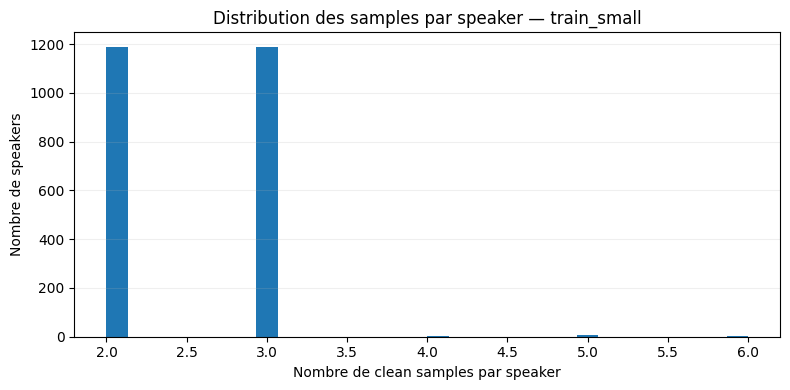

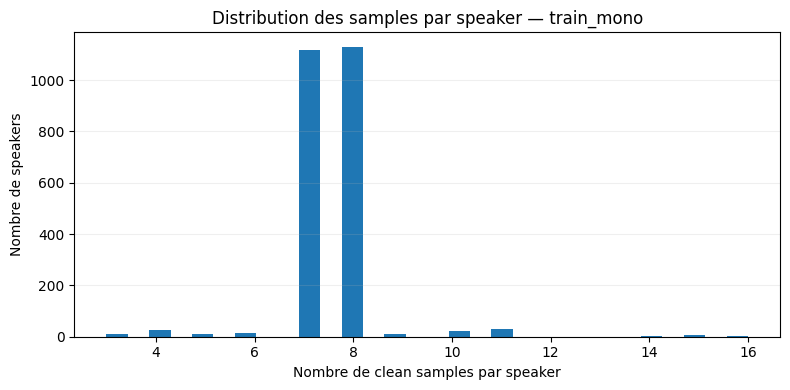

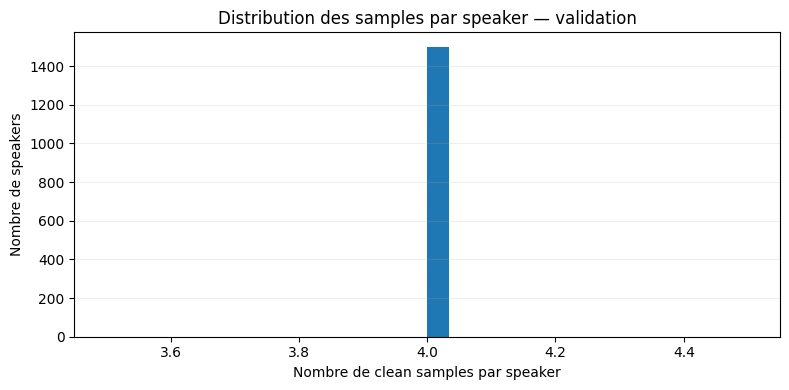

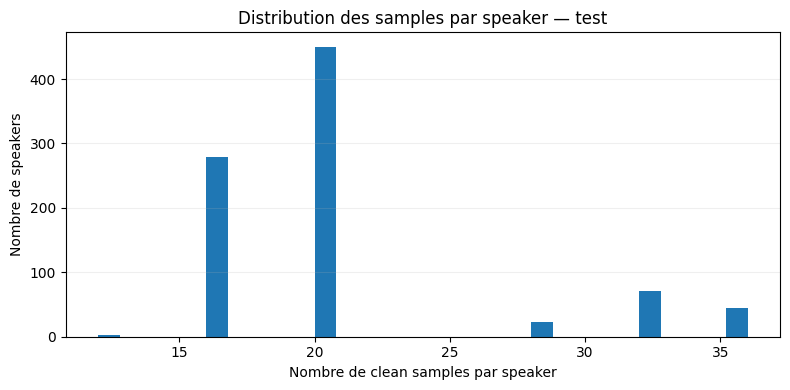


DIVERSITÉ DES SPEAKERS PAR LANGUE


,language,samples,speakers,dataset,samples/speaker
12,de,4500,225,test,20.000000
13,es,4500,282,test,15.957447
14,fr,4500,225,test,20.000000
15,zh-CN,4500,138,test,32.608696
4,de,4500,600,train_mono,7.500000
5,es,4500,600,train_mono,7.500000
6,fr,4500,600,train_mono,7.500000
7,zh-CN,4500,600,train_mono,7.500000
0,de,1500,600,train_small,2.500000
1,es,1500,600,train_small,2.500000



SPEAKERS UTILISÉS DANS PLUSIEURS LANGUES


,dataset,speakers,speakers_in_multiple_languages,percentage
0,train_small,2389,11,0.460444
1,train_mono,2389,11,0.460444
2,validation,1500,0,0.000000
3,test,870,0,0.000000



OVERLAP DES SPEAKERS ENTRE DATASETS


,dataset_1,dataset_2,speakers_1,speakers_2,shared_speakers,overlap_%_dataset_1,overlap_%_dataset_2
0,train_small,train_mono,2389,2389,2389,100.0,100.0
1,train_small,validation,2389,1500,0,0.0,0.0
2,train_small,test,2389,870,0,0.0,0.0
3,train_mono,validation,2389,1500,0,0.0,0.0
4,train_mono,test,2389,870,0,0.0,0.0
5,validation,test,1500,870,0,0.0,0.0



OVERLAP DES CLEAN ENTRE DATASETS


,dataset_1,dataset_2,clean_1,clean_2,shared_clean,overlap_%_dataset_1,overlap_%_dataset_2
0,train_small,train_mono,6000,18000,807,13.45,4.483333
1,train_small,validation,6000,1500,0,0.00,0.000000
2,train_small,test,6000,4500,0,0.00,0.000000
3,train_mono,validation,18000,1500,0,0.00,0.000000
4,train_mono,test,18000,4500,0,0.00,0.000000
5,validation,test,1500,4500,0,0.00,0.000000


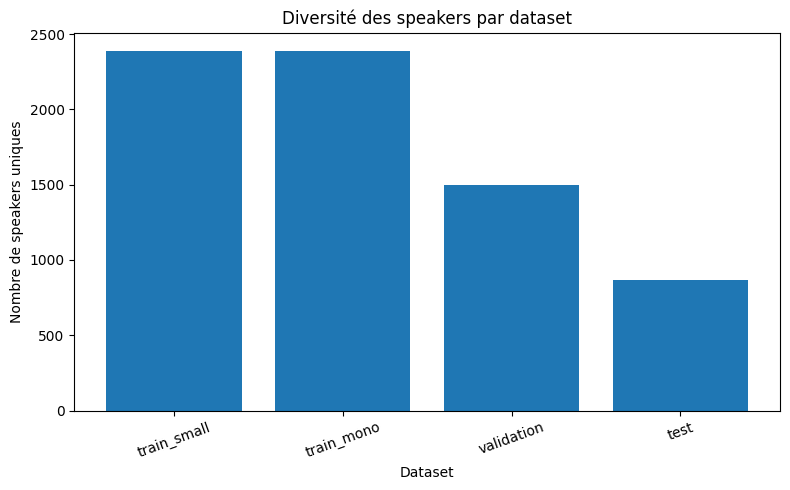

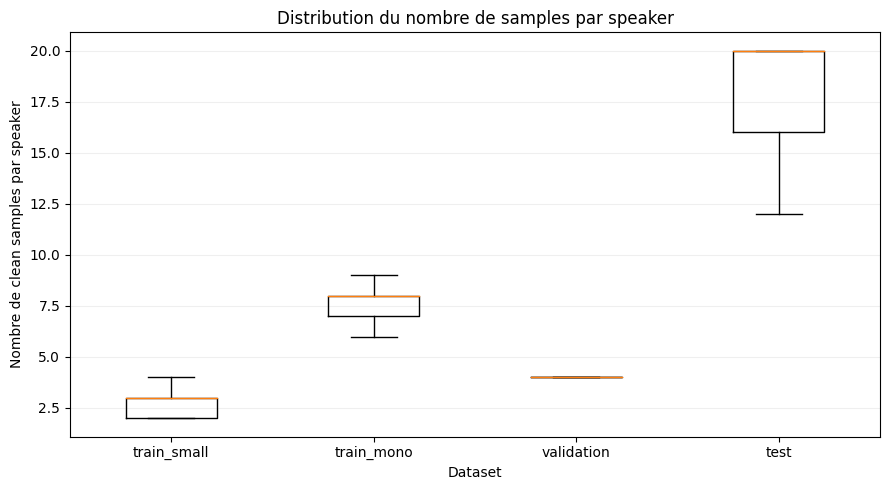


DIVERSITÉ RELATIVE DES SPEAKERS


,dataset,samples,speakers,speakers_per_1000_samples
0,train_small,6000,2389,398.166667
2,validation,6000,1500,250.000000
1,train_mono,18000,2389,132.722222
3,test,18000,870,48.333333



RÉSUMÉ
✓ train_small     |   6,000 samples |  2,389 speakers |   4 langues | split = train.tsv
✓ train_mono      |  18,000 samples |  2,389 speakers |   4 langues | split = train.tsv
✓ validation      |   6,000 samples |  1,500 speakers |   4 langues | split = validated.tsv
✓ test            |  18,000 samples |    870 speakers |   4 langues | split = test.tsv


In [4]:
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# CONFIGURATION
# ============================================================

json_files = {
    "train_small": "./noisy_CWWS_train_small.json",
    "train_mono": "./noisy_CWWS_train_mono.json",
    "validation": "./noisy_CWWS_validation.json",
    "test": "./noisy_CWWS_test.json",
}

# Organisation :
#
# tsv_files/
# ├── fr/
# │   ├── train.tsv
# │   ├── validated.tsv
# │   └── test.tsv
# ├── en/
# │   ├── train.tsv
# │   ├── validated.tsv
# │   └── test.tsv
# └── ...
#
path_tsv_files = Path(
    "/home/fderrida/Desktop/mount_jz_scratch/"
    "domainbed/data/URGENT/corpus/CommonVoice/tsv_files/"
)

# Split CommonVoice correspondant à chaque JSON
expected_tsv = {
    "train_small": "train.tsv",
    "train_mono": "train.tsv",
    "validation": "validated.tsv",
    "test": "test.tsv",
}


# ============================================================
# UTILITAIRES
# ============================================================

def get_filename(path):
    """Extrait le nom du fichier."""
    return Path(path).name


def get_language_from_clean(clean):
    """
    Extrait la langue depuis le chemin du clean.

    Exemple :
        fr/clips/01/common_voice_fr_123.mp3
        -> fr
    """
    parts = Path(clean).parts

    if not parts:
        raise ValueError(
            f"Impossible d'extraire la langue de : {clean}"
        )

    return parts[0]


def load_json(json_path):
    """Charge un JSON."""
    with open(json_path, "r", encoding="utf-8") as f:
        return json.load(f)


def load_tsv(language, split):
    """
    Charge uniquement le TSV nécessaire :

        tsv_files/<language>/<split>
    """

    tsv_path = path_tsv_files / language / split

    if not tsv_path.exists():
        raise FileNotFoundError(
            f"TSV introuvable : {tsv_path}"
        )

    df = pd.read_csv(
        tsv_path,
        sep="\t",
        dtype={
            "client_id": "string",
            "path": "string",
            "locale": "string",
        },
        usecols=[
            "client_id",
            "path",
            "locale",
        ],
        keep_default_na=False,
    )

    # On garde uniquement le nom du fichier.
    df["filename"] = df["path"].map(Path).map(lambda x: x.name)

    return df


# ============================================================
# 1. CHARGEMENT DES JSON
# ============================================================

json_data = {}

for dataset_name, json_path in json_files.items():

    json_path = Path(json_path)

    if not json_path.exists():
        raise FileNotFoundError(
            f"JSON introuvable : {json_path.resolve()}"
        )

    json_data[dataset_name] = load_json(json_path)


# ============================================================
# 2. IDENTIFICATION DES LANGUES PAR DATASET
# ============================================================

dataset_languages = {}

for dataset_name, data in json_data.items():

    languages = sorted({
        get_language_from_clean(sample["clean"])
        for sample in data["data"]
    })

    dataset_languages[dataset_name] = languages


# ============================================================
# 3. CHARGEMENT MINIMAL DES TSV
#
# On ne charge que :
#
#     langue + split réellement nécessaire
#
# et chaque combinaison une seule fois.
# ============================================================

tsv_cache = {}

for dataset_name, languages in dataset_languages.items():

    split = expected_tsv[dataset_name]

    for language in languages:

        key = (language, split)

        if key not in tsv_cache:
            tsv_cache[key] = load_tsv(
                language,
                split,
            )


# ============================================================
# 4. CONSTRUCTION D'UN INDEX RAPIDE
#
# clé :
#     (language, split, filename)
#
# valeur :
#     client_id
#
# On utilise set_index plutôt que iterrows().
# ============================================================

tsv_indexes = {}

for (language, split), df in tsv_cache.items():

    # Si un même filename apparaît plusieurs fois,
    # on garde la première occurrence.
    df_unique = df.drop_duplicates(
        subset="filename",
        keep="first",
    )

    index = df_unique.set_index("filename")

    tsv_indexes[(language, split)] = index


# ============================================================
# 5. VALIDATION DES 4 DATASETS
# ============================================================

all_results = {}

validation_summary = []


for dataset_name, data in json_data.items():

    expected_split = expected_tsv[dataset_name]

    records = []

    missing = []

    language_mismatch = []

    for i, sample in enumerate(data["data"]):

        clean = sample["clean"]

        language = get_language_from_clean(clean)

        filename = get_filename(clean)

        index = tsv_indexes[
            (language, expected_split)
        ]

        # ----------------------------------------------------
        # Vérification de présence dans le split attendu
        # ----------------------------------------------------

        if filename not in index.index:

            missing.append({
                "index": i,
                "clean": clean,
                "filename": filename,
                "language": language,
            })

            continue

        row = index.loc[filename]

        # ----------------------------------------------------
        # Speaker
        # ----------------------------------------------------

        speaker = row["client_id"]

        # ----------------------------------------------------
        # Vérification locale
        # ----------------------------------------------------

        tsv_locale = row["locale"]

        if tsv_locale != language:

            language_mismatch.append({
                "index": i,
                "clean": clean,
                "json_language": language,
                "tsv_locale": tsv_locale,
            })

        # ----------------------------------------------------
        # On ne garde que les informations utiles
        # ----------------------------------------------------

        records.append({
            "dataset": dataset_name,
            "clean": clean,
            "filename": filename,
            "speaker": speaker,
            "language": language,
        })

    df = pd.DataFrame(records)

    all_results[dataset_name] = df

    validation_summary.append({
        "dataset": dataset_name,
        "expected_split": expected_split,
        "json_samples": len(data["data"]),
        "matched_samples": len(df),
        "missing_samples": len(missing),
        "language_mismatches": len(language_mismatch),
        "speakers": df["speaker"].nunique(),
        "languages": df["language"].nunique(),
    })


# ============================================================
# 6. RÉSUMÉ DE VALIDATION
# ============================================================

validation_df = pd.DataFrame(
    validation_summary
)

print("\nVALIDATION DES SPLITS")
display(validation_df)


# ============================================================
# 7. DÉTAIL DES ERREURS ÉVENTUELLES
# ============================================================

# On ne construit les détails que s'il y a réellement
# des problèmes.

validation_errors = {}

for dataset_name, data in json_data.items():

    expected_split = expected_tsv[dataset_name]

    missing = []
    language_mismatch = []

    # On refait uniquement la vérification des erreurs.
    # Cela évite de garder de grosses structures en mémoire.

    for i, sample in enumerate(data["data"]):

        clean = sample["clean"]

        language = get_language_from_clean(clean)

        filename = get_filename(clean)

        index = tsv_indexes[
            (language, expected_split)
        ]

        if filename not in index.index:

            missing.append({
                "index": i,
                "clean": clean,
                "filename": filename,
                "language": language,
            })

            continue

        row = index.loc[filename]

        if row["locale"] != language:

            language_mismatch.append({
                "index": i,
                "clean": clean,
                "json_language": language,
                "tsv_locale": row["locale"],
            })

    validation_errors[dataset_name] = {
        "missing": pd.DataFrame(missing),
        "language_mismatch": pd.DataFrame(
            language_mismatch
        ),
    }


# Afficher uniquement les problèmes
for dataset_name, errors in validation_errors.items():

    if len(errors["missing"]) > 0:

        print(
            f"\n⚠️ {dataset_name} : "
            f"{len(errors['missing'])} clean absents "
            f"du split attendu"
        )

        display(errors["missing"].head(20))

    if len(errors["language_mismatch"]) > 0:

        print(
            f"\n⚠️ {dataset_name} : "
            f"{len(errors['language_mismatch'])} "
            f"mismatches de langue"
        )

        display(
            errors["language_mismatch"].head(20)
        )


# ============================================================
# 8. STATISTIQUES DE DIVERSITÉ DES SPEAKERS
# ============================================================

dataset_stats = []

for dataset_name, df in all_results.items():

    speaker_counts = (
        df
        .groupby("speaker")
        .size()
    )

    n_speakers = df["speaker"].nunique()

    dataset_stats.append({

        "dataset": dataset_name,

        "samples": len(df),

        "speakers": n_speakers,

        "languages": df["language"].nunique(),

        "samples/speaker_mean": (
            speaker_counts.mean()
            if len(speaker_counts)
            else np.nan
        ),

        "samples/speaker_median": (
            speaker_counts.median()
            if len(speaker_counts)
            else np.nan
        ),

        "samples/speaker_std": (
            speaker_counts.std()
            if len(speaker_counts)
            else np.nan
        ),

        "samples/speaker_min": (
            speaker_counts.min()
            if len(speaker_counts)
            else np.nan
        ),

        "samples/speaker_max": (
            speaker_counts.max()
            if len(speaker_counts)
            else np.nan
        ),
    })


dataset_stats_df = pd.DataFrame(
    dataset_stats
)

print("\nSTATISTIQUES DE DIVERSITÉ DES SPEAKERS")
display(dataset_stats_df)


# ============================================================
# 9. DISTRIBUTION DU NOMBRE DE SAMPLES PAR SPEAKER
# ============================================================

for dataset_name, df in all_results.items():

    speaker_counts = (
        df
        .groupby("speaker")
        .size()
    )

    plt.figure(figsize=(8, 4))

    plt.hist(
        speaker_counts,
        bins=30,
    )

    plt.xlabel(
        "Nombre de clean samples par speaker"
    )

    plt.ylabel(
        "Nombre de speakers"
    )

    plt.title(
        f"Distribution des samples par speaker — "
        f"{dataset_name}"
    )

    plt.grid(
        axis="y",
        alpha=0.2,
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# 10. SPEAKERS PAR LANGUE
# ============================================================

speaker_language_stats = []

for dataset_name, df in all_results.items():

    grouped = (
        df
        .groupby("language")
        .agg(
            samples=("clean", "size"),
            speakers=("speaker", "nunique"),
        )
        .reset_index()
    )

    grouped["dataset"] = dataset_name

    grouped["samples/speaker"] = (
        grouped["samples"]
        / grouped["speakers"]
    )

    speaker_language_stats.append(
        grouped
    )


speaker_language_df = pd.concat(
    speaker_language_stats,
    ignore_index=True,
)


print("\nDIVERSITÉ DES SPEAKERS PAR LANGUE")
display(
    speaker_language_df.sort_values(
        ["dataset", "language"]
    )
)


# ============================================================
# 11. SPEAKERS PRÉSENTS DANS PLUSIEURS LANGUES
#
# Cela permet de vérifier la contrainte :
#
# speaker_unique_across_languages = true
# ============================================================

multi_language_rows = []

for dataset_name, df in all_results.items():

    speaker_languages = (
        df
        .groupby("speaker")["language"]
        .nunique()
    )

    multi = speaker_languages[
        speaker_languages > 1
    ]

    multi_language_rows.append({
        "dataset": dataset_name,
        "speakers": len(speaker_languages),
        "speakers_in_multiple_languages": len(multi),
        "percentage": (
            100 * len(multi)
            / len(speaker_languages)
            if len(speaker_languages)
            else 0
        ),
    })


multi_language_df = pd.DataFrame(
    multi_language_rows
)

print(
    "\nSPEAKERS UTILISÉS DANS PLUSIEURS LANGUES"
)

display(multi_language_df)


# ============================================================
# 12. OVERLAP DES SPEAKERS ENTRE LES DATASETS
#
# C'est probablement la vérification la plus importante
# pour tes splits.
# ============================================================

dataset_speakers = {
    dataset_name: set(df["speaker"])
    for dataset_name, df in all_results.items()
}


dataset_names = list(
    dataset_speakers.keys()
)


speaker_overlap_rows = []


for i in range(len(dataset_names)):

    for j in range(i + 1, len(dataset_names)):

        d1 = dataset_names[i]
        d2 = dataset_names[j]

        s1 = dataset_speakers[d1]
        s2 = dataset_speakers[d2]

        shared = s1 & s2

        speaker_overlap_rows.append({

            "dataset_1": d1,

            "dataset_2": d2,

            "speakers_1": len(s1),

            "speakers_2": len(s2),

            "shared_speakers": len(shared),

            "overlap_%_dataset_1": (
                100 * len(shared) / len(s1)
                if len(s1)
                else 0
            ),

            "overlap_%_dataset_2": (
                100 * len(shared) / len(s2)
                if len(s2)
                else 0
            ),
        })


speaker_overlap_df = pd.DataFrame(
    speaker_overlap_rows
)


print(
    "\nOVERLAP DES SPEAKERS ENTRE DATASETS"
)

display(speaker_overlap_df)


# ============================================================
# 13. VÉRIFICATION DES CLEAN PARTAGÉS ENTRE DATASETS
#
# On compare uniquement les fichiers clean.
# ============================================================

dataset_cleans = {
    dataset_name: set(df["clean"])
    for dataset_name, df in all_results.items()
}


clean_overlap_rows = []


for i in range(len(dataset_names)):

    for j in range(i + 1, len(dataset_names)):

        d1 = dataset_names[i]
        d2 = dataset_names[j]

        c1 = dataset_cleans[d1]
        c2 = dataset_cleans[d2]

        shared = c1 & c2

        clean_overlap_rows.append({

            "dataset_1": d1,

            "dataset_2": d2,

            "clean_1": len(c1),

            "clean_2": len(c2),

            "shared_clean": len(shared),

            "overlap_%_dataset_1": (
                100 * len(shared) / len(c1)
                if len(c1)
                else 0
            ),

            "overlap_%_dataset_2": (
                100 * len(shared) / len(c2)
                if len(c2)
                else 0
            ),
        })


clean_overlap_df = pd.DataFrame(
    clean_overlap_rows
)


print(
    "\nOVERLAP DES CLEAN ENTRE DATASETS"
)

display(clean_overlap_df)


# ============================================================
# 14. NOMBRE DE SPEAKERS PAR DATASET
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    dataset_stats_df["dataset"],
    dataset_stats_df["speakers"],
)

plt.ylabel(
    "Nombre de speakers uniques"
)

plt.xlabel(
    "Dataset"
)

plt.title(
    "Diversité des speakers par dataset"
)

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()


# ============================================================
# 15. BOXPLOT : NOMBRE DE SAMPLES PAR SPEAKER
#
# Comparaison directe des distributions.
# ============================================================

boxplot_data = []

boxplot_labels = []


for dataset_name, df in all_results.items():

    counts = (
        df
        .groupby("speaker")
        .size()
    )

    boxplot_data.append(
        counts.values
    )

    boxplot_labels.append(
        dataset_name
    )


plt.figure(figsize=(9, 5))

plt.boxplot(
    boxplot_data,
    labels=boxplot_labels,
    showfliers=False,
)

plt.ylabel(
    "Nombre de clean samples par speaker"
)

plt.xlabel(
    "Dataset"
)

plt.title(
    "Distribution du nombre de samples par speaker"
)

plt.grid(
    axis="y",
    alpha=0.2,
)

plt.tight_layout()

plt.show()


# ============================================================
# 16. DIVERSITÉ RELATIVE
#
# Ratio :
#
#       speakers / samples
#
# Plus ce ratio est élevé, plus le dataset est diversifié
# en termes de speakers.
# ============================================================

diversity_df = dataset_stats_df[
    [
        "dataset",
        "samples",
        "speakers",
    ]
].copy()

diversity_df[
    "speakers_per_1000_samples"
] = (
    diversity_df["speakers"]
    / diversity_df["samples"]
    * 1000
)


print(
    "\nDIVERSITÉ RELATIVE DES SPEAKERS"
)

display(
    diversity_df
    .sort_values(
        "speakers_per_1000_samples",
        ascending=False,
    )
)


# ============================================================
# 17. RÉSUMÉ FINAL TRÈS COMPACT
# ============================================================

print("\n" + "=" * 70)
print("RÉSUMÉ")
print("=" * 70)

for _, row in validation_df.iterrows():

    status = (
        "✓"
        if row["missing_samples"] == 0
        and row["language_mismatches"] == 0
        else "⚠️"
    )

    print(
        f"{status} "
        f"{row['dataset']:15s} | "
        f"{row['matched_samples']:>7,} samples | "
        f"{row['speakers']:>6,} speakers | "
        f"{row['languages']:>3} langues | "
        f"split = {row['expected_split']}"
    )

print("=" * 70)

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


def plot_speakers_per_language(
    path_tsv_files,
    splits=("train.tsv", "validated.tsv", "test.tsv"),
):
    """
    Compte et affiche le nombre de speakers uniques (client_id)
    pour chaque langue et chaque split CommonVoice.

    Parameters
    ----------
    path_tsv_files : str or Path
        Dossier contenant les sous-dossiers de langues.

        Exemple:
        /.../CommonVoice/tsv_files/

        avec:
            fr/train.tsv
            fr/validated.tsv
            fr/test.tsv
            en/train.tsv
            ...

    splits : tuple
        TSV à analyser.

    Returns
    -------
    speaker_counts : pd.DataFrame
        Tableau avec :
            language | split | speakers
    """

    path_tsv_files = Path(path_tsv_files)

    if not path_tsv_files.exists():
        raise FileNotFoundError(
            f"Dossier introuvable : {path_tsv_files}"
        )

    rows = []

    # --------------------------------------------------------
    # Parcours des langues
    # --------------------------------------------------------

    languages = sorted(
        p.name
        for p in path_tsv_files.iterdir()
        if p.is_dir()
    )

    for language in languages:

        for split in splits:

            tsv_path = (
                path_tsv_files
                / language
                / split
            )

            # Certains splits peuvent ne pas exister
            if not tsv_path.exists():
                continue

            df = pd.read_csv(
                tsv_path,
                sep="\t",
                dtype=str,
                keep_default_na=False,
                usecols=["client_id"],
            )

            n_speakers = df["client_id"].nunique()

            rows.append({
                "language": language,
                "split": split,
                "speakers": n_speakers,
            })

    # --------------------------------------------------------
    # Résultats
    # --------------------------------------------------------

    speaker_counts = pd.DataFrame(rows)

    if speaker_counts.empty:
        raise ValueError(
            "Aucun TSV valide trouvé."
        )

    # --------------------------------------------------------
    # Tableau pivot
    # --------------------------------------------------------

    plot_df = speaker_counts.pivot(
        index="language",
        columns="split",
        values="speakers",
    )

    # Ordre des splits
    split_order = [
        split
        for split in splits
        if split in plot_df.columns
    ]

    plot_df = plot_df[split_order]

    # Trier les langues par nombre total de speakers
    plot_df = plot_df.loc[
        plot_df.sum(axis=1)
        .sort_values(ascending=False)
        .index
    ]

    # --------------------------------------------------------
    # Figure
    # --------------------------------------------------------

    ax = plot_df.plot(
        kind="bar",
        figsize=(15, 7),
    )

    ax.set_xlabel("Language")
    ax.set_ylabel("Number of unique speakers")
    ax.set_title(
        "Number of unique speakers per language "
        "and CommonVoice split"
    )

    ax.tick_params(
        axis="x",
        rotation=45,
    )

    ax.grid(
        axis="y",
        alpha=0.2,
    )

    ax.legend(
        title="Split"
    )

    plt.tight_layout()
    plt.show()

    return speaker_counts

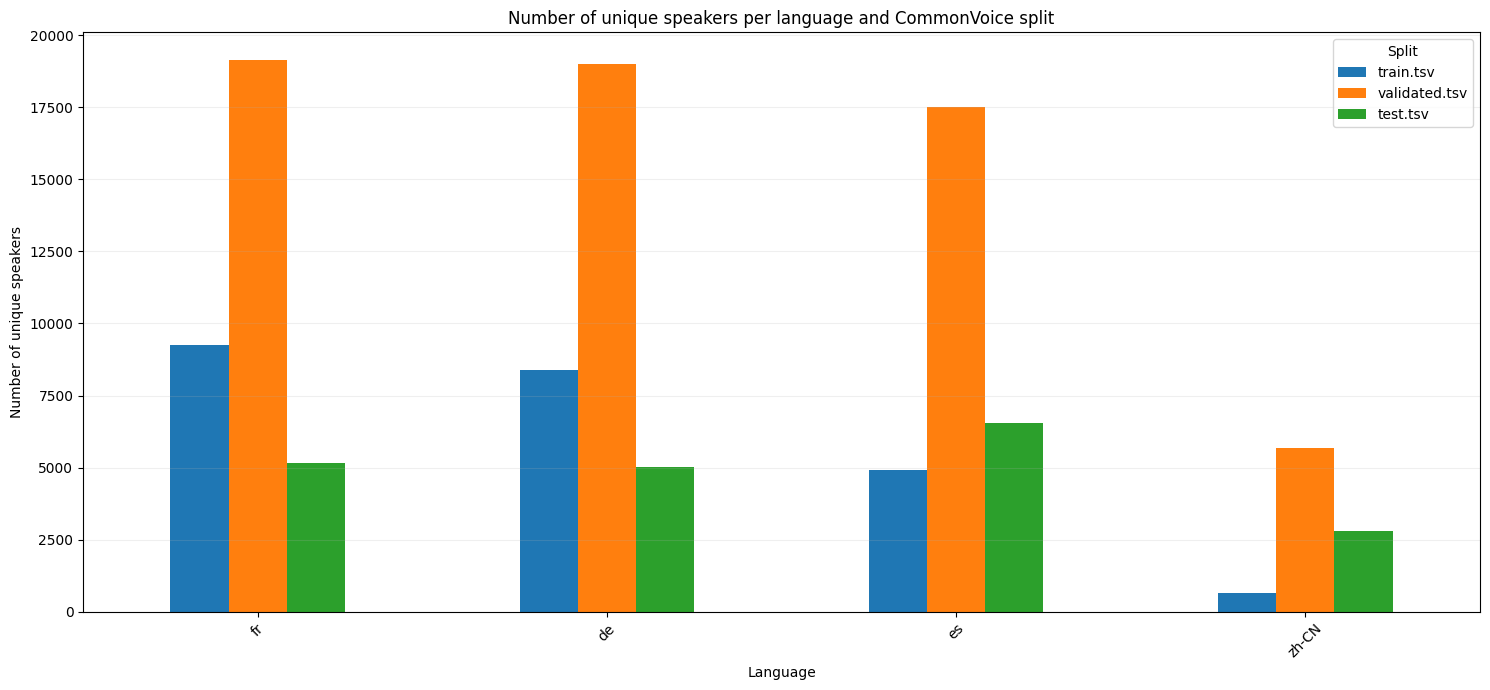

,language,split,speakers
0,de,train.tsv,8374
1,de,validated.tsv,18986
2,de,test.tsv,5031
3,es,train.tsv,4922
4,es,validated.tsv,17515
5,es,test.tsv,6550
6,fr,train.tsv,9242
7,fr,validated.tsv,19140
8,fr,test.tsv,5147
9,zh-CN,train.tsv,664


In [6]:
plot_speakers_per_language(path_tsv_files)